In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import StringIO

s3 = boto3.client("s3")

# Load Open-Meteo file from S3
bucket = "gridsense-azhuk-test" 
file_key = "openmeteo/openmeteo_weather_2022_2024.csv"

obj = s3.get_object(Bucket=bucket, Key=file_key)
raw = obj["Body"].read().decode("utf-8")

df = pd.read_csv(StringIO(raw), skiprows=3)

df.columns = df.columns.str.strip()
df['time'] = pd.to_datetime(df['time'])
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
print(df.head())

Shape: (26304, 8)

Columns: ['time', 'temperature_2m (°C)', 'windspeed_10m (km/h)', 'windspeed_100m (km/h)', 'cloudcover (%)', 'shortwave_radiation (W/m²)', 'precipitation (mm)', 'windgusts_10m (km/h)']

Head:
                 time  temperature_2m (°C)  windspeed_10m (km/h)  \
0 2022-01-01 00:00:00                 23.9                  17.7   
1 2022-01-01 01:00:00                 22.7                  18.4   
2 2022-01-01 02:00:00                 22.0                  18.3   
3 2022-01-01 03:00:00                 21.3                  18.6   
4 2022-01-01 04:00:00                 21.0                  21.9   

   windspeed_100m (km/h)  cloudcover (%)  shortwave_radiation (W/m²)  \
0                   33.4              48                        19.0   
1                   33.2              54                         0.0   
2                   32.7              42                         0.0   
3                   33.5              43                         0.0   
4                   3

In [53]:
# Data types, missing values, and date conversion
df = df.rename(columns={
    'temperature_2m (°C)': 'temperature',
    'windspeed_10m (km/h)': 'windspeed_10m',
    'windspeed_100m (km/h)': 'windspeed_100m',
    'cloudcover (%)': 'cloudcover',
    'shortwave_radiation (W/m²)': 'shortwave_radiation',
    'precipitation (mm)': 'precipitation',
    'windgusts_10m (km/h)': 'windgusts'
})

df = df.drop(columns=['precipitation'])
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDate Range:")
print("Start:", df['time'].min())
print("End:", df['time'].max())
print("\nSummary Statistics:")
print(df.describe())

print(f"\nFinal shape after dropping precipitation: {df.shape}")
# Should show (26304, 7)

Data Types:
time                   datetime64[ns]
temperature                   float64
windspeed_10m                 float64
windspeed_100m                float64
cloudcover                      int64
shortwave_radiation           float64
windgusts                     float64
dtype: object

Missing Values:
time                   0
temperature            0
windspeed_10m          0
windspeed_100m         0
cloudcover             0
shortwave_radiation    0
windgusts              0
dtype: int64

Date Range:
Start: 2022-01-01 00:00:00
End: 2024-12-31 23:00:00

Summary Statistics:
                      time   temperature  windspeed_10m  windspeed_100m  \
count                26304  26304.000000   26304.000000    26304.000000   
mean   2023-07-02 23:30:00     21.256273      13.265534       21.082706   
min    2022-01-01 00:00:00     -9.700000       0.000000        0.000000   
25%    2022-10-01 23:45:00     15.100000       8.200000       14.100000   
50%    2023-07-02 23:30:00     22.300000  

In [44]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check for outliers using IQR
print("\nOutlier Detection:")
for col in ['temperature', 'windspeed_10m', 'cloudcover', 'shortwave_radiation', 'windspeed_100m']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: {outliers} outliers (lower bound: {lower:.2f}, upper bound: {upper:.2f})")

Duplicate rows: 0

Outlier Detection:
  temperature: 116 outliers (lower bound: -3.69, upper bound: 46.41)
  windspeed_10m: 339 outliers (lower bound: -5.60, upper bound: 31.20)
  cloudcover: 0 outliers (lower bound: -150.00, upper bound: 250.00)
  shortwave_radiation: 39 outliers (lower bound: -585.00, upper bound: 975.00)
  windspeed_100m: 192 outliers (lower bound: -5.70, upper bound: 47.10)


In [46]:
print("\nTemperature outlier investigation:")
hot = df[df['temperature'] > 46.41]
print(f"Records above 46.41°C: {len(hot)}")
print(f"Max temperature recorded: {df['temperature'].max():.1f}°C")
print(f"Min temperature recorded: {df['temperature'].min():.1f}°C")
print("No extreme temperature outliers detected.")
print("Max of 41.5°C is consistent with Austin TX summer heat events - data is clean.")


Temperature outlier investigation:
Records above 46.41°C: 0
Max temperature recorded: 41.5°C
Min temperature recorded: -9.7°C
No extreme temperature outliers detected.
Max of 41.5°C is consistent with Austin TX summer heat events - data is clean.


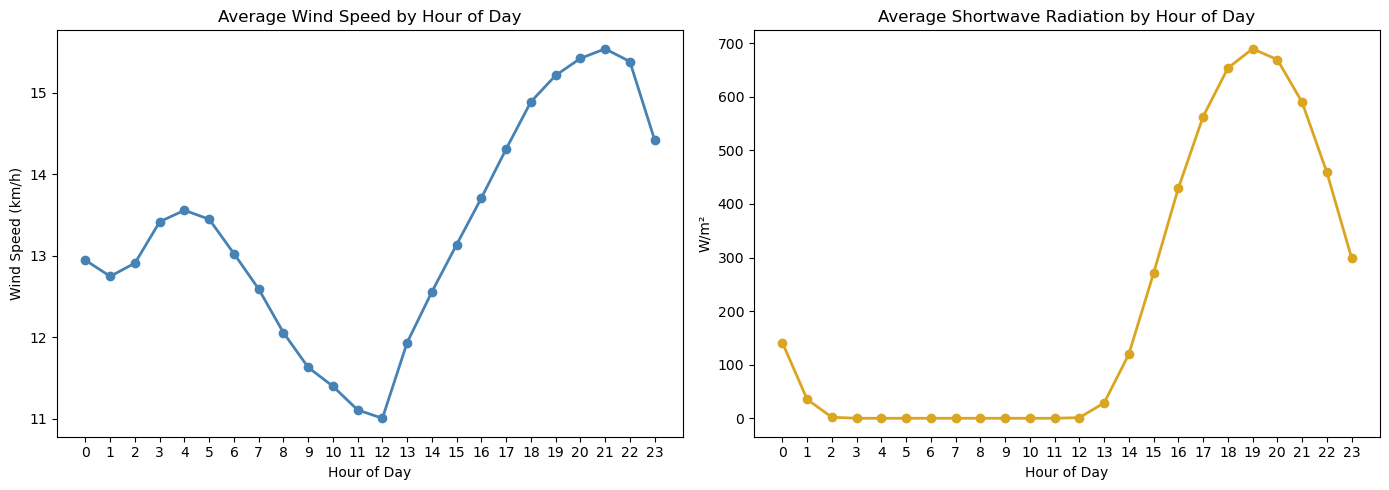

Plot saved.


In [47]:
# Average wind speed and shortwave radiation by hour of day
df['hour'] = df['time'].dt.hour

hourly_avg = df.groupby('hour')[['windspeed_10m', 'shortwave_radiation']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_avg.index, hourly_avg['windspeed_10m'], 
             color='steelblue', marker='o', linewidth=2)
axes[0].set_title('Average Wind Speed by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Wind Speed (km/h)')
axes[0].set_xticks(range(0, 24))

axes[1].plot(hourly_avg.index, hourly_avg['shortwave_radiation'], 
             color='goldenrod', marker='o', linewidth=2)
axes[1].set_title('Average Shortwave Radiation by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('W/m²')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('openmeteo_hourly_patterns.png')
plt.show()
print("Plot saved.")

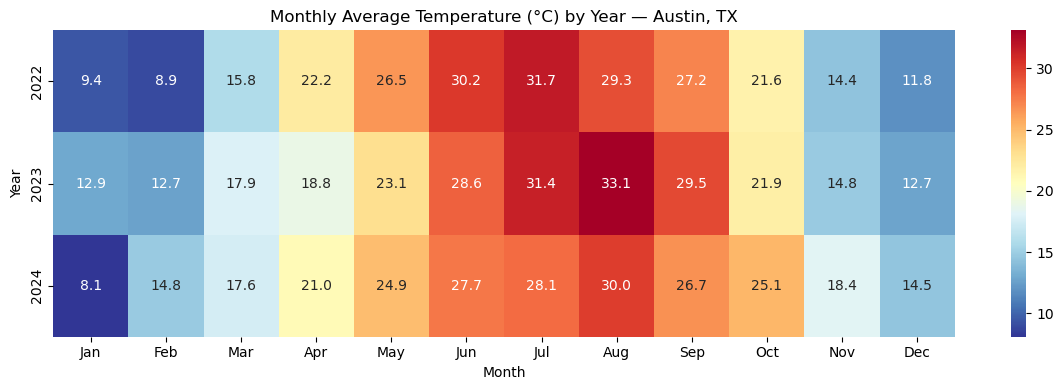

Plot saved.


In [48]:
# Monthly average temperature heatmap
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

monthly_temp = df.groupby(['year', 'month'])['temperature'].mean().unstack()

plt.figure(figsize=(12, 4))
sns.heatmap(monthly_temp, annot=True, fmt='.1f', cmap='RdYlBu_r',
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'],
            yticklabels=['2022','2023','2024'])
plt.title('Monthly Average Temperature (°C) by Year — Austin, TX')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('openmeteo_temp_heatmap.png')
plt.show()
print("Plot saved.")

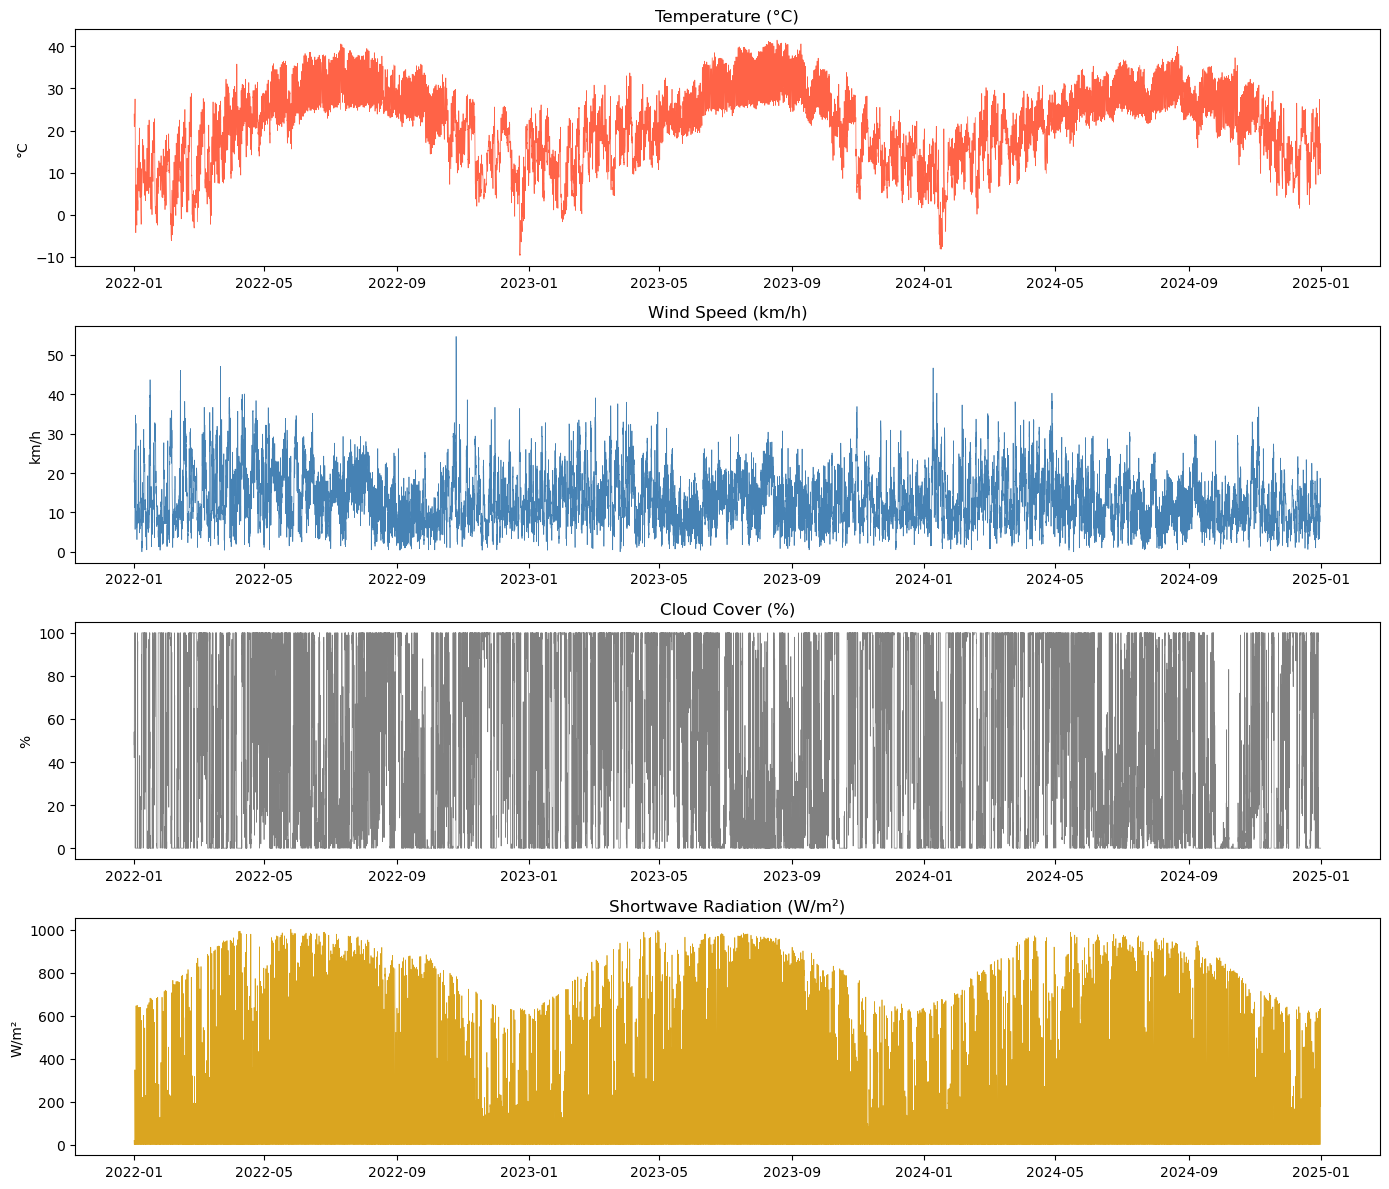

Plot saved.


In [49]:
# Plot all four weather variables over time
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(df['time'], df['temperature'], linewidth=0.5, color='tomato')
axes[0].set_title('Temperature (°C)')
axes[0].set_ylabel('°C')

axes[1].plot(df['time'], df['windspeed_10m'], linewidth=0.5, color='steelblue')
axes[1].set_title('Wind Speed (km/h)')
axes[1].set_ylabel('km/h')

axes[2].plot(df['time'], df['cloudcover'], linewidth=0.5, color='gray')
axes[2].set_title('Cloud Cover (%)')
axes[2].set_ylabel('%')

axes[3].plot(df['time'], df['shortwave_radiation'], linewidth=0.5, color='goldenrod')
axes[3].set_title('Shortwave Radiation (W/m²)')
axes[3].set_ylabel('W/m²')

plt.tight_layout()
plt.savefig('openmeteo_variables.png')
plt.show()
print("Plot saved.")

## Open-Meteo Data Exploration Summary

**Dataset:** Open-Meteo Historical Weather API (Austin, TX — ERCOT Region)
**Shape:** 26,304 rows × 7 columns
**Date Range:** January 1, 2022 to December 31, 2024

### Key Findings

- Zero null values and zero duplicate rows — complete hourly records
- 26,304 rows matches ERCOT EIA dataset exactly — ready for merging
- Temperature ranges from -9.7°C to 41.5°C capturing seasonal extremes
- Shortwave radiation shows strong seasonal pattern — peaks in summer, near zero in winter nights
- Cloud cover is highly variable, frequently at 0% or 100%
- Monthly temperature heatmap shows July and August are consistently the hottest months across all three years
- 2023 early January recorded the coldest temperatures in the dataset, dropping near -5°C — capturing winter demand spikes critical for grid stress modeling
- Shortwave radiation peaks at hours 19-20 (~690 W/m²) — solar generation strongest in late afternoon Austin TX time (data is in UTC — hour 19-20 UTC = 1-2 PM local CST)
- Wind speed is lowest at hour 11-12 (11.0 km/h) and peaks at hours 20-21 (15.7 km/h)
- Solar generation is near zero before hour 13 and after hour 22. Wind speed is at its daily minimum during peak solar hours (11-12), creating a supply gap window that is a critical signal for grid stress prediction
- Wind speed outliers represent real weather extremes and were retained
- Precipitation column dropped — redundant with cloudcover and shortwave_radiation
- Open-Meteo data is stored in UTC (utc_offset_seconds = 0). Hour 19-20 UTC = 1-2 PM CST (Austin local time) — confirming solar peaks at the expected early afternoon local time


### Data Quality Concerns
- Time column loaded as object dtype — converted to datetime
- Wind speed and shortwave radiation outliers are valid extreme weather events 
  and were retained for model training
- Precipitation excluded due to zero-inflated distribution and redundancy 
  with cloud cover features

### Bias Considerations
- **Geographic bias:** Weather data is from Austin, TX (30.3N, 97.7W) — 
  aligned with ERCOT region and EIA ERCOT balancing authority focus
- **Seasonal bias:** Dataset spans 3 full years capturing all seasons 
  equally — low seasonal bias risk
- **Reporting bias:** No known revision policy for Open-Meteo historical 
  data — assumed to be stable